## Q1

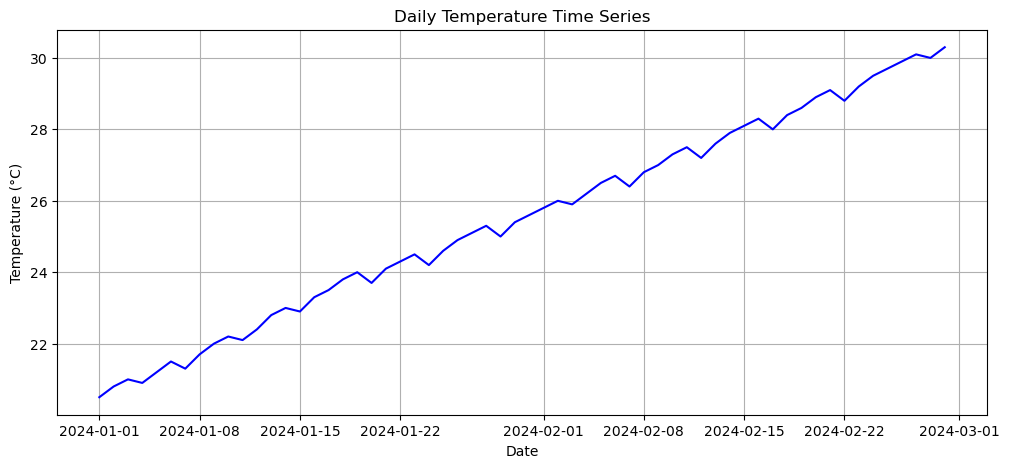

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("temperature.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

plt.figure(figsize=(12,5))
plt.plot(df["Temperature"], color="blue")
plt.title("Daily Temperature Time Series")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

## Q2

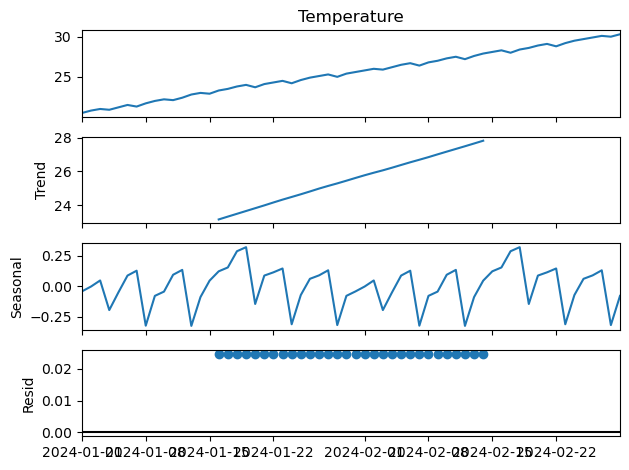

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df["Temperature"],
    model="additive",
    period=30      
)

result.plot()

plt.show()

## Q3

In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Temperature"])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

if result[1] < 0.05:
    print("The series is Stationary")
else:
    print("The series is NOT Stationary")

ADF Statistic : -0.7101674475980323
p-value       : 0.8440983326068999
The series is NOT Stationary


## Q4

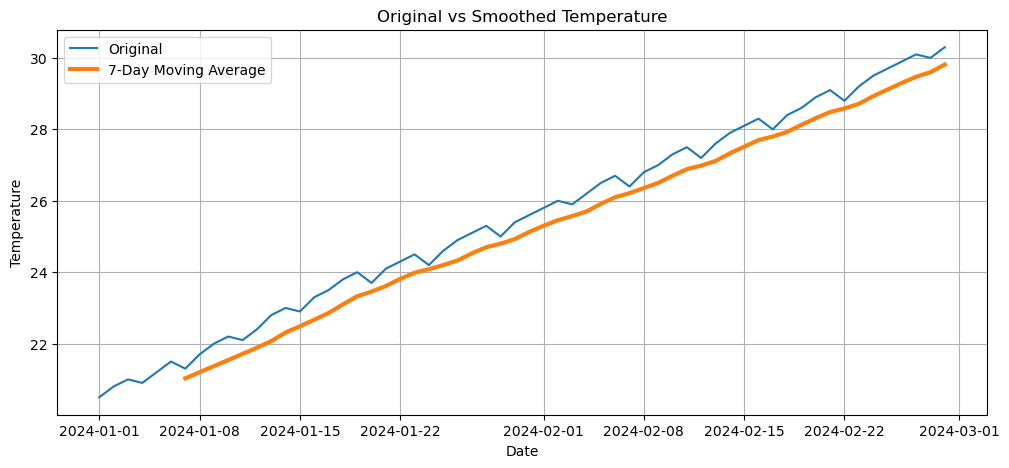

In [ ]:

df["Moving_Average"] = df["Temperature"].rolling(window=7).mean()

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    df["Temperature"],
    label="Original"
)

plt.plot(
    df.index,
    df["Moving_Average"],
    label="7-Day Moving Average",
    linewidth=3
)

plt.title("Original vs Smoothed Temperature")

plt.xlabel("Date")
plt.ylabel("Temperature")

plt.legend()

plt.grid(True)

plt.show()

## Q5

c:\Users\RAJEET\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\RAJEET\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\RAJEET\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\RAJEET\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\RAJEET\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA par

Next 7-Day Forecast:
2024-03-01    30.336076
2024-03-02    30.303078
2024-03-03    30.313021
2024-03-04    30.285717
2024-03-05    30.290789
2024-03-06    30.267787
2024-03-07    30.269198
Freq: D, Name: predicted_mean, dtype: float64


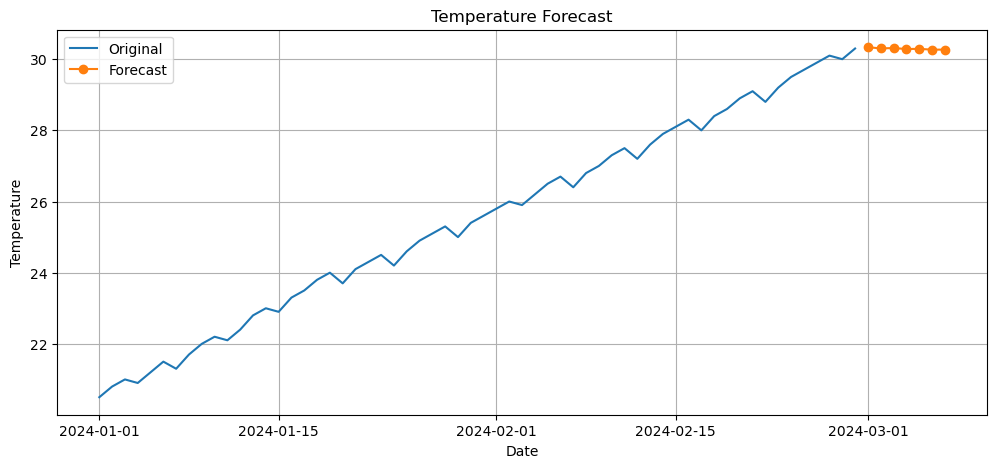

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

model = ARIMA(
    df["Temperature"],
    order=(2,0,2)      
)

model_fit = model.fit()

forecast = model_fit.forecast(steps=7)

print("Next 7-Day Forecast:")

print(forecast)

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    df["Temperature"],
    label="Original"
)

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=7
)

plt.plot(
    future_dates,
    forecast,
    marker="o",
    label="Forecast"
)

plt.title("Temperature Forecast")

plt.xlabel("Date")
plt.ylabel("Temperature")

plt.legend()

plt.grid(True)

plt.show()